# MATH 465 Fall 2026: Module 1 — k-means

Xiuyuan Cheng  
xiuyuan.cheng@duke.edu

Verify the environment and installation.

In [1]:
import sys
import numpy as np
import sklearn

print("Python executable:", sys.executable)
print("NumPy version:", np.__version__)
print("scikit-learn version:", sklearn.__version__)

I = np.eye(100)
assert np.array_equal(I @ I, I)
print("MATH 465 environment is ready.")


Python executable: /opt/homebrew/Caskroom/miniconda/base/envs/math465/bin/python
NumPy version: 2.4.3
scikit-learn version: 1.8.0
MATH 465 environment is ready.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

scikit-learn's ``make_blobs`` function generates isotropic Gaussian blobs as simulated data for clustering.

By default, the data are two-dimensional (this can be changed using the ``n_features`` argument). The number and centers of the clusters (three clusters by default), as well as the standard deviation of each Gaussian component (1.0 by default), can be changed by the user.

See the [documentation page](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html#sklearn.datasets.make_blobs).


In [3]:
n_samples = 400
random_state = 2026 # fix the random seed to obtain reproducible simulation results

true_cluster_centers =np.array([[5.0, 1], [-1.0, 0.5], [1, -2]])


X, y = make_blobs(n_samples=n_samples, 
                  centers=true_cluster_centers,
                  random_state=random_state)


In [4]:
X.shape

(400, 2)

Text(0.5, 1.0, 'data to cluster')

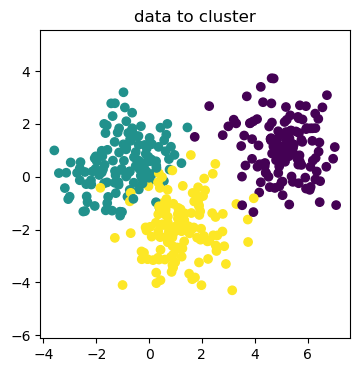

In [5]:
# plot the data colored by class labels
plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.axis('equal') # use equal axis scaling so distances in R^2 are not distorted
plt.title("data to cluster")

In [6]:
# apply k-means
kmeansOutput = KMeans(n_clusters= 3, n_init = 10, random_state=random_state).fit(X)

In [7]:
kmeansOutput

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",2026
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


The ``KMeans`` function in scikit-learn has several useful options:

- The argument ``init`` specifies the method used to select the initial cluster centers.

- The argument ``n_init`` specifies the number of initializations to run; the best result is returned.

- Other arguments are also useful. In particular, ``verbose`` mode prints more information about the progress of the algorithm.


See the [documentation page](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) for more information.


Remark. In general, check whether algorithms in software packages provide a ``verbose`` mode. The additional information can be useful for using the algorithm correctly, debugging failures, and improving runtime.

In [8]:
y_pred = kmeansOutput.labels_

print("Inertia:", kmeansOutput.inertia_) # sum of squared distances from samples to their closest cluster center


Inertia: 781.0184414173249


In [9]:
# what are the estimated cluster centers?
kmeansOutput.cluster_centers_


array([[ 5.08825769,  1.08898612],
       [-0.90537907,  0.49619133],
       [ 1.21861073, -2.05686186]])

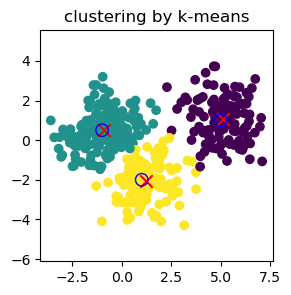

In [10]:
# plot the result
plt.figure(figsize=(3, 3))
plt.scatter(X[:, 0], X[:, 1], c=y_pred) #colored by predicted labels
plt.scatter(kmeansOutput.cluster_centers_[:, 0], kmeansOutput.cluster_centers_[:, 1], 
            marker='x', color = 'r', s = 80 )

plt.scatter(true_cluster_centers[:, 0], true_cluster_centers[:, 1], 
            marker='o', facecolors='none', color = 'b', s = 80 )

plt.axis('equal')
plt.title("clustering by k-means")

plt.show()

# What if apply with n_clusters wrong? (HW1)

- The verbose print

In [11]:
kmeansOutput = KMeans(n_clusters= 3, 
                      random_state=random_state,
                      n_init = 5, 
                      verbose = 1,
                     ).fit(X)

y_pred = kmeansOutput.labels_
print("Selected final inertia:", kmeansOutput.inertia_)

Initialization complete
Iteration 0, inertia 1518.559603089802.
Iteration 1, inertia 938.0334151974307.
Iteration 2, inertia 796.9719354557503.
Iteration 3, inertia 782.4799198602724.
Iteration 4, inertia 781.0184414173249.
Converged at iteration 4: strict convergence.
Initialization complete
Iteration 0, inertia 1572.0944390668437.
Iteration 1, inertia 787.4599143089795.
Iteration 2, inertia 781.122402747949.
Iteration 3, inertia 781.0184414173249.
Converged at iteration 3: strict convergence.
Initialization complete
Iteration 0, inertia 1022.6566348274301.
Iteration 1, inertia 791.584027365314.
Iteration 2, inertia 781.0631868442329.
Converged at iteration 2: center shift 0.0003421643207659515 within tolerance 0.0005031576006571717.
Initialization complete
Iteration 0, inertia 1271.373371670897.
Iteration 1, inertia 829.8908104144252.
Iteration 2, inertia 783.7824169126567.
Iteration 3, inertia 781.0184414173249.
Converged at iteration 3: strict convergence.
Initialization complete
I

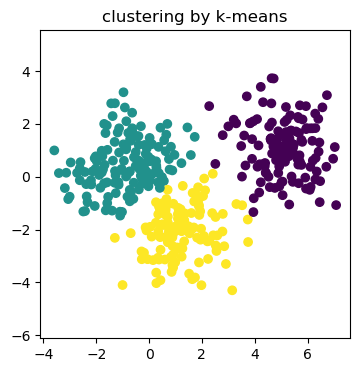

In [12]:
# plot the result
plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.axis('equal')
plt.title("clustering by k-means")

plt.show()

# Half of Lloyd's algorithm

We perform the assignment step of Lloyd's algorithm.

- Manually specifying the centers

Inertia using fitted centers: 781.0184414173249
Inertia using true centers: 790.0082341598722


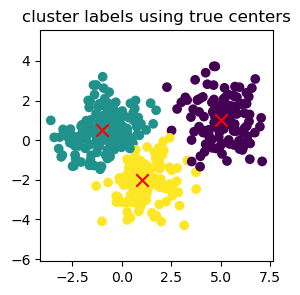

In [13]:
# change the centers to the true centers

fitted_inertia = kmeansOutput.inertia_

kmeansOutput.cluster_centers_ = true_cluster_centers
    # we can specify different centers and then assign each test sample 
    # to its nearest center

#kmeansOutput.cluster_centers_ = true_cluster_centers+2 

y_pred2 = kmeansOutput.predict(X)
inertia2 = np.sum((X - kmeansOutput.cluster_centers_[y_pred2]) ** 2)

print("Inertia using fitted centers:", fitted_inertia)
print("Inertia using true centers:", inertia2)

# plot the result
plt.figure(figsize=(3, 3))
plt.scatter(X[:, 0], X[:, 1], c=y_pred2)
plt.scatter(kmeansOutput.cluster_centers_[:, 0], kmeansOutput.cluster_centers_[:, 1], 
            marker='x', color = 'r', s = 80 )
plt.axis('equal')
plt.title("cluster labels using true centers")

plt.show()

Replacing the centers and calling `predict` performs only the assignment step of Lloyd's algorithm: 

the centers are fixed and each point is assigned to its nearest center. 

The fitted centers have slightly lower inertia because they were optimized for this sample; 

the true generating centers need not minimize the sample inertia.

Number of points classified differently: 1


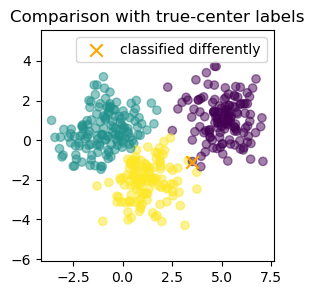

In [14]:
# Find the one-to-one label permutation with the most matches.
from itertools import permutations

best_match_count = -1
for permutation in permutations(range(3)):
    candidate_map = np.array(permutation)
    match_count = np.sum(candidate_map[y_pred] == y_pred2)
    if match_count > best_match_count:
        best_match_count = match_count
        label_map = candidate_map

y_pred_aligned = label_map[y_pred]
different = y_pred_aligned != y_pred2
#print("Best label map:", label_map)
print("Number of points classified differently:", different.sum())

plt.figure(figsize=(3, 3))
plt.scatter(X[:, 0], X[:, 1], c=y_pred2, alpha=0.5)
plt.scatter(X[different, 0], X[different, 1],
            marker="x", color="orange", s=80,
            label="classified differently")
plt.axis("equal")
plt.title("Comparison with true-center labels")
plt.legend()
plt.show()


- Demo of the assignment on test samples

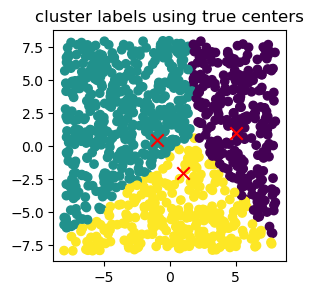

In [15]:
# generate test samples and predict their labels

X_test = np.random.rand(1000,2)
X_test[:,0]=(X_test[:,0]-0.5)*2*8 #[-8,8]
X_test[:,1]=(X_test[:,1]-0.5)*2*8

y_test = kmeansOutput.predict(X_test)

# plot the result
plt.figure(figsize=(3, 3))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.scatter(kmeansOutput.cluster_centers_[:, 0], kmeansOutput.cluster_centers_[:, 1], 
            marker='x', color = 'r', s = 80 )
plt.axis('equal')
plt.title("cluster labels using true centers")

plt.show()

# Hard cases for k-means

- The case where the cluster sizes are imbalanced


(np.float64(-4.362372173406249),
 np.float64(8.226634853061084),
 np.float64(-4.031788495208784),
 np.float64(3.9521535089720383))

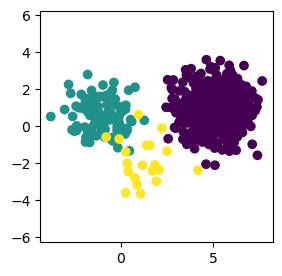

In [16]:
# Unevenly sized blobs

n_samples = 1500
random_state = 2023


true_cluster_centers =np.array([[5.0, 1], [-1.0, 0.5], [1, -2]])

X, y = make_blobs(n_samples=n_samples, 
                  centers=true_cluster_centers,
                  random_state=random_state)


n1, n2, n3 = 500, 100, 20
X_filtered = np.vstack((X[y == 0][:n1], X[y == 1][:n2], X[y == 2][:n3]))
y_filtered = np.zeros(n1+n2+n3)
y_filtered[0:n1]=0
y_filtered[n1:n1+n2]=1
y_filtered[n1+n2:n1+n2+n3]=2


# plot the data colored by class labels
plt.figure(figsize=(3, 3))
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
plt.axis('equal') # use equal axis scaling so distances in R^2 are not distorted
#plt.title("Cluster data")


Initialization complete
Iteration 0, inertia 1198.186545866416.
Iteration 1, inertia 1060.2455147031533.
Iteration 2, inertia 1046.6426395348715.
Iteration 3, inertia 1038.5338696574927.
Iteration 4, inertia 1032.352728705858.
Iteration 5, inertia 1024.789150212343.
Iteration 6, inertia 1020.0269811541618.
Iteration 7, inertia 1017.9934409970301.
Iteration 8, inertia 1013.6234347448378.
Iteration 9, inertia 1011.6123211324983.
Iteration 10, inertia 1010.2888757880245.
Iteration 11, inertia 1008.776898236388.
Iteration 12, inertia 1007.3522468399624.
Iteration 13, inertia 1006.9424824024284.
Iteration 14, inertia 1006.5902323152792.
Converged at iteration 14: center shift 0.0001970525882894331 within tolerance 0.0003693646085617847.
Initialization complete
Iteration 0, inertia 1283.9620670473926.
Iteration 1, inertia 1029.16812742484.
Iteration 2, inertia 1023.8384882858027.
Iteration 3, inertia 1021.9372338325427.
Iteration 4, inertia 1020.9684941495426.
Iteration 5, inertia 1019.74250

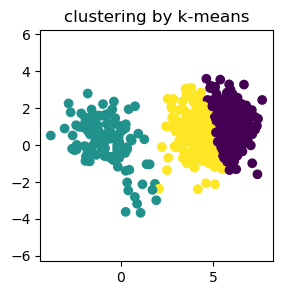

In [17]:
kmeansOutput = KMeans(n_clusters= 3, 
                      random_state=random_state,
                      n_init = 5, 
                      verbose = 1,
                     ).fit(X_filtered)

y_pred = kmeansOutput.labels_
print("Selected final inertia:", kmeansOutput.inertia_)

# plot the result
plt.figure(figsize=(3, 3))
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
plt.axis('equal')
plt.title("clustering by k-means")

plt.show()

Question: How can we improve the result? What if the centers are known?

You will continue to examine difficult cases in the homework.

---